## Machine Learning Workshop - Crewes 2020: Convolution Neural Networks Explained
In this lab we will look at how Convolutional Neural Networks work by looking at classification examples. \
This lecture is based on Chapter 14 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow, \
and Chapter 5 on Fracois Chollet's book, Deep Learning with Python (Mannings Publications).
The notebook code can be found in github [here](https://github.com/dtrad/geoml_course).\
You can run this notebook in Google colab by clicking in the link below.

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/CNN_Explained.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Example 1: Fully Connected (Dense) Network vs Convolutional Neural Network.
Compare a Fully Connected Network (FCN) with a Convolution Neural Network (CNN) for the same dataset.

### Example 1 - Step 1 - Loading data 
We will load the MNIST dataset (description [here](https://en.wikipedia.org/wiki/MNIST_database))\
Also, we will normalize the pixel values by substracting the mean and dividing by the standard deviatio.\
Finally we will separate into the train, validation and testing datasets.\
To treat each digit as an image, we need to add the feature axis, 1 in this case because it is black-white image.



In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

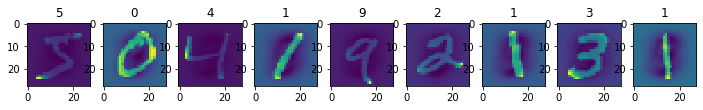

In [3]:
plt.figure(figsize=(12,12))
for i in range(9):
        plt.subplot(191+i),plt.imshow(X_train[i,:,:,0]);plt.title(y_train[i]);

In [4]:
#Let us see the array sizes
print('X_train ',X_train.shape)
print('X_valid ',X_valid.shape)
print('X_test  ',X_test.shape)

X_train  (55000, 28, 28, 1)
X_valid  (5000, 28, 28, 1)
X_test   (10000, 28, 28, 1)


### Example 1 - Step 2 - Fully Connected Layer.
For comparison, we will first create a FCN (not the ideal for computer vision)\
These networks do not have translational invariance and therefore need different filters for the same patterns at different locations. \
FCN assume the input has the shape (nbatches, nelements) (2 dimensions) so we need to flatten the images first. 

In [5]:
model1d = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model1d.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [6]:
model1d.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [8]:
history1d=model1d.fit(X_train[:,:,:,0],y_train,epochs=10,validation_data=(X_valid[:,:,:,0],y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 69us/sample - loss: 1.2254 - accuracy: 0.6508 - val_loss: 0.5774 - val_accuracy: 0.8642
Epoch 2/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.5278 - accuracy: 0.8583 - val_loss: 0.3695 - val_accuracy: 0.9106
Epoch 3/10
55000/55000 [==============================] - 3s 59us/sample - loss: 0.3936 - accuracy: 0.8895 - val_loss: 0.2987 - val_accuracy: 0.9248
Epoch 4/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.3322 - accuracy: 0.9045 - val_loss: 0.2623 - val_accuracy: 0.9318
Epoch 5/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.2948 - accuracy: 0.9146 - val_loss: 0.2382 - val_accuracy: 0.9364
Epoch 6/10
55000/55000 [==============================] - 3s 57us/sample - loss: 0.2685 - accuracy: 0.9221 - val_loss: 0.2224 - val_accuracy: 0.9414
Epoch 7/10
55000/55000 [==============================] -

In [9]:
#Let us see the mean square error (MSE)
MSE_DN=model1d.evaluate(X_test[:,:,:,0],y_test)
print("MSE for FCC = ", MSE_DN)

10000/10000 [==============================] - 0s 38us/sample - loss: 127.5175 - accuracy: 0.9365
MSE for FCC =  [127.5175414351508, 0.9365]


In [10]:
def plot_history(history):
    plt.figure(figsize=(8,3))
    plt.subplot(121),plt.plot(history.history['accuracy'],label='training');plt.plot(history.history['val_accuracy'],label='validation');plt.title('accuracy')
    plt.legend()
    plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
    plt.legend()

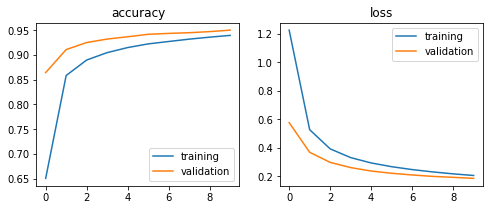

In [11]:
plot_history(history1d)

### Example 1 - Step 3 - Convolutional Network
We start by taking the images (1 channel) and creating 32 feature maps. \
Then we reduce the image size by 2 and double the channels.\
Repeat until we get to the desired image size (3x3) nad map to a dense layer to finish the classification

In [12]:
from tensorflow.keras import layers
from tensorflow.keras import models

model2d = models.Sequential()
model2d.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model2d.add(layers.MaxPooling2D((2, 2)))
model2d.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2d.add(layers.MaxPooling2D((2, 2)))
model2d.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2d.add(layers.Flatten())
model2d.add(layers.Dense(64, activation='relu'))
model2d.add(layers.Dense(10, activation='softmax'))

In [13]:
model2d.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 3, 3, 64)          36928     
_________________________________________________________________
flatten_1 (Flatten)          (None, 576)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 64)               

In [14]:
model2d.compile(optimizer='rmsprop',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

In [15]:
history2d=model2d.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 7s 134us/sample - loss: 0.1326 - accuracy: 0.9585 - val_loss: 0.0567 - val_accuracy: 0.9874
Epoch 2/10
55000/55000 [==============================] - 5s 93us/sample - loss: 0.0435 - accuracy: 0.9864 - val_loss: 0.0595 - val_accuracy: 0.9876
Epoch 3/10
55000/55000 [==============================] - 5s 93us/sample - loss: 0.0328 - accuracy: 0.9901 - val_loss: 0.0495 - val_accuracy: 0.9906
Epoch 4/10
55000/55000 [==============================] - 5s 91us/sample - loss: 0.0266 - accuracy: 0.9930 - val_loss: 0.0723 - val_accuracy: 0.9898
Epoch 5/10
55000/55000 [==============================] - 5s 92us/sample - loss: 0.0215 - accuracy: 0.9939 - val_loss: 0.0831 - val_accuracy: 0.9868
Epoch 6/10
55000/55000 [==============================] - 5s 91us/sample - loss: 0.0195 - accuracy: 0.9947 - val_loss: 0.0789 - val_accuracy: 0.9890
Epoch 7/10
55000/55000 [==============================] 

In [16]:
model2d.evaluate(X_test,y_test)

10000/10000 [==============================] - 1s 51us/sample - loss: 5406.6546 - accuracy: 0.9901


[5406.654628450684, 0.9901]

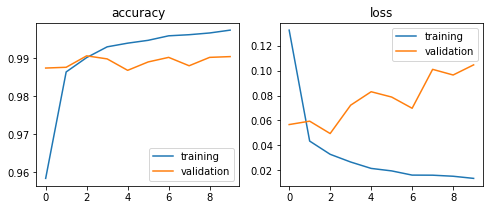

In [17]:
plot_history(history2d)

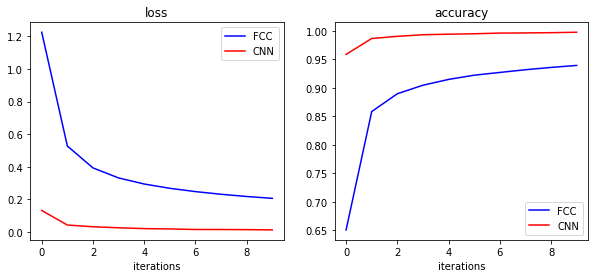

In [18]:
def plot_histories(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_histories(history1d,history2d,'FCC','CNN')

### Example 1 - Step 4 - Comparing predictions

In [19]:
ntest=20;
print(y_test[:ntest])

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [20]:
#notice for the 1D model (FCN) we need to flat the input 
y_predict1d=model1d.predict(X_test[:ntest,:,:,0])
y_predict2d=model2d.predict(X_test[:ntest])

The predict method gives us the probabilities that each instance (20 of them) belongs to each of the 10 classes in the output.

In [21]:
print(y_predict1d.shape)
print(y_predict2d.shape)

(20, 10)
(20, 10)


In [22]:
print(['index','true','pred1d','pred2d'])
[print(i,'\t',y_test[i], '\t',y_predict1d[i,:].argmax(), '\t',y_predict2d[i,:].argmax()) for i in range(0,ntest)];

['index', 'true', 'pred1d', 'pred2d']
0 	 7 	 7 	 7
1 	 2 	 2 	 2
2 	 1 	 1 	 1
3 	 0 	 0 	 0
4 	 4 	 4 	 4
5 	 1 	 1 	 1
6 	 4 	 4 	 4
7 	 9 	 9 	 9
8 	 5 	 6 	 5
9 	 9 	 9 	 9
10 	 0 	 0 	 0
11 	 6 	 6 	 6
12 	 9 	 9 	 9
13 	 0 	 0 	 0
14 	 1 	 1 	 1
15 	 5 	 5 	 5
16 	 9 	 9 	 9
17 	 7 	 7 	 7
18 	 3 	 3 	 3
19 	 4 	 4 	 4


Instance 18 was classified wrongling by the CNN. Let us see it

3 3 3
3 0.5416404 0.99999976


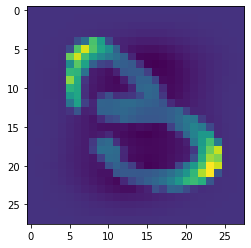

In [23]:
nn=18
print(y_test[nn], y_predict1d[nn,:].argmax(), y_predict2d[nn,:].argmax())
print(y_test[nn], y_predict1d[nn,3], y_predict2d[nn,3])
[plt.imshow(X_test[nn,:,:,0]) for i in range(0,10)];

For home, you can try a bigger layer, for example this. See if you get a better result for the instance 18. 

### Example 1 - Step 5 - Feature maps
Let us examine the feature maps on each layer

In [24]:
from tensorflow.keras import models

# Extracts the outputs of the top 8 layers:
layer_outputs = [layer.output for layer in model2d.layers[:4]]
# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model2d.input, outputs=layer_outputs)

In [25]:
print(X_train[:1,:,:,:].shape)

(1, 28, 28, 1)


In [26]:
# This will return a list of 5 Numpy arrays: one array per layer activation
activations = activation_model.predict(X_train[:1])

(1, 26, 26, 32)
(1, 13, 13, 32)
(1, 11, 11, 64)
(1, 5, 5, 64)


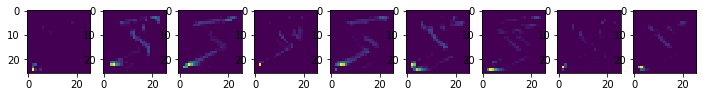

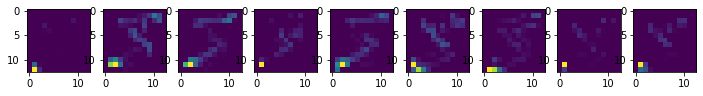

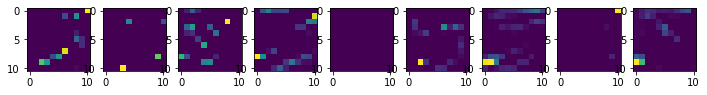

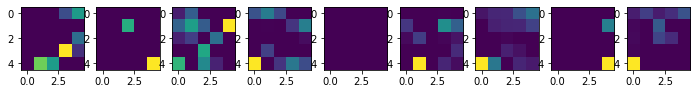

In [27]:
nlayers=len(activations)
for j in range(nlayers):
    this_activation = activations[j]
    print(this_activation.shape)
    plt.figure(figsize=(12,12))
    nfeatures = this_activation.shape[3]    
    nfigures=min(9,nfeatures)
    for i in range(nfigures):
        plt.subplot(191+i),plt.imshow(this_activation[0,:,:,i]);

## Example 2: Transfer learning
In this case we will see a more difficult example. We will try binary classification (easier) but in more complex images.\
Because we want to do this very quickly in the time of this workshop, we will use the fastest possible way.\
We will download a pretrained network (trained in a different problem), and then we will change the last part only.\

We will start by unpacking the data in the zip drive. \
If you have your data in a google drive,you can mount your drive and copy the contents like it is shown in the first 3 lines.\
If you have them in your local disk, use the upload bottom on Google Collab (may take a few minutes) and then uncomment the last 2 lines (only).

In [54]:
#from google.colab import drive
#drive.mount('/content/drive')
#!cp /content/drive/MyDrive/Geo-ML/data/catsdogs.zip .
#!mkdir data
#!unzip cat*.zip -d data

### Example 2 - Step 1: Pretrained network
Let us get a pretrained network.

In [55]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

In [30]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 150, 150, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 150, 150, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 150, 150, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 75, 75, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 75, 75, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 75, 75, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 37, 37, 128)       0     

### Example 2 - Step 2: Generate features
Let us use the pretrained networks to extract the main features from the images.

In [31]:

#image='/home/dtrad/data/dogs-cats/cats_and_dogs_small/train/cats/cat.0.jpg'
# if working in collab use
MYDIR='/content/data/'
# if working locally use your directory, for example
MYDIR='/home/dtrad/data/dogs-cats/cats_and_dogs_small'


In [32]:
import os
base_dir = MYDIR
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

Using TensorFlow backend.


Found 2000 images belonging to 2 classes.
class [1.]
class [0.]
class [1.]
class [0.]


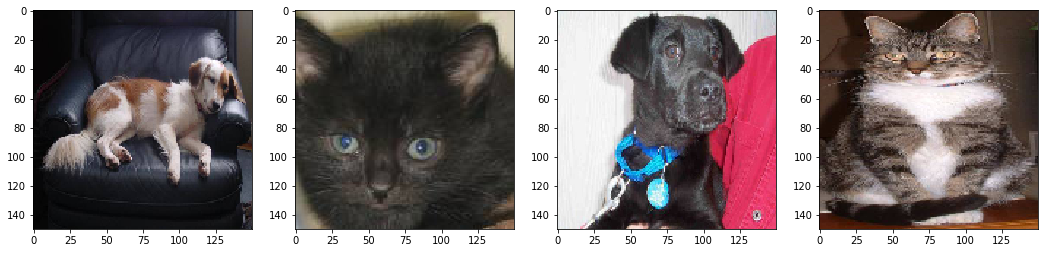

In [33]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)
generator=datagen.flow_from_directory(train_dir, target_size=(150,150), batch_size=1, class_mode='binary')
count=0
plt.figure(figsize=(18,18))
for input_batch, labels_batch in generator:
    plt.subplot(141+count),plt.imshow(input_batch[0,:,:,:])
    count+=1
    print('class',labels_batch)
    if (count ==4):
        break


In [34]:
import numpy as np
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            # Note that since generators yield data indefinitely in a loop,
            # we must `break` after every image has been seen once.
            break
    return features, labels

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
test_features, test_labels = extract_features(test_dir, 1000)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Notice the output of the last conv_base network has shape (None, 4, 4, 512). That means that produces 512 features, each of size 4x4.\
The first dimension is free (number of samples). 

In [35]:
print(train_features.shape, train_labels.shape)

(2000, 4, 4, 512) (2000,)


Text(0.5, 1.0, 'one feature from the last layer')

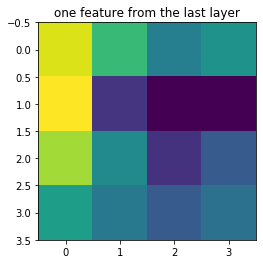

In [36]:
plt.imshow(train_features[0,:,:,0]);
plt.title('one feature from the last layer')

In [37]:
print(train_labels[:10])

[0. 1. 1. 1. 0. 0. 0. 0. 0. 0.]


### Example 2 - Step 3: Classification
Use the extraced features to classify the image.\
We need to map the train_features to a vector.



In [38]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

In [39]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer=optimizers.RMSprop(lr=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])

history = model.fit(train_features, train_labels,
                    epochs=30,
                    batch_size=20,
                    validation_data=(validation_features, validation_labels))

Train on 2000 samples, validate on 1000 samples
Epoch 1/30
2000/2000 [==============================] - 1s 398us/sample - loss: 0.6056 - acc: 0.6710 - val_loss: 0.4426 - val_acc: 0.8270
Epoch 2/30
2000/2000 [==============================] - 0s 157us/sample - loss: 0.4234 - acc: 0.8125 - val_loss: 0.3634 - val_acc: 0.8430
Epoch 3/30
2000/2000 [==============================] - 0s 155us/sample - loss: 0.3614 - acc: 0.8470 - val_loss: 0.3234 - val_acc: 0.8760
Epoch 4/30
2000/2000 [==============================] - 0s 155us/sample - loss: 0.3089 - acc: 0.8735 - val_loss: 0.3030 - val_acc: 0.8820
Epoch 5/30
2000/2000 [==============================] - 0s 152us/sample - loss: 0.2815 - acc: 0.8850 - val_loss: 0.2843 - val_acc: 0.8860
Epoch 6/30
2000/2000 [==============================] - 0s 150us/sample - loss: 0.2572 - acc: 0.8935 - val_loss: 0.2726 - val_acc: 0.8910
Epoch 7/30
2000/2000 [==============================] - 0s 149us/sample - loss: 0.2458 - acc: 0.9015 - val_loss: 0.2697 - va

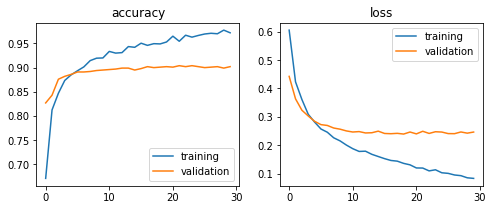

In [40]:
def plot_history(history):
    plt.figure(figsize=(8,3))
    plt.subplot(121),plt.plot(history.history['acc'],label='training');plt.plot(history.history['val_acc'],label='validation');plt.title('accuracy')
    plt.legend()
    plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
    plt.legend()
plot_history(history)

## Example 3: visualizing feature maps
Now we will instect feature maps. This exercise will take longer so we will leave it for you to run at home.


### Example 3: CNN from scratch
Let us create a CNN from scratch, similarly as we did for the MNIST. 
This network is a bit larger because the images are larger. 

In [41]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',
                        input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(lr=1e-4),
              metrics=['acc'])

In [42]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 34, 34, 128)       73856     
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 17, 17, 128)       0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 15, 15, 128)      

In [43]:
from keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
        # This is the target directory
        train_dir,
        # All images will be resized to 150x150
        target_size=(150, 150),
        batch_size=20,
        # Since we use binary_crossentropy loss, we need binary labels
        class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
        validation_dir,
        target_size=(150, 150),
        batch_size=20,
        class_mode='binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Let us train with the dogs and cats dataset

In [44]:
history = model.fit_generator(
      train_generator,
      steps_per_epoch=100,
      epochs=30,
      validation_data=validation_generator,
      validation_steps=50)

Instructions for updating:
Please use Model.fit, which supports generators.
  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 100 steps, validate for 50 steps
Epoch 1/30
100/100 [==============================] - 11s 106ms/step - loss: 0.6922 - acc: 0.5280 - val_loss: 0.6912 - val_acc: 0.5090
Epoch 2/30
100/100 [==============================] - 10s 98ms/step - loss: 0.6760 - acc: 0.5700 - val_loss: 0.6565 - val_acc: 0.6150
Epoch 3/30
100/100 [==============================] - 10s 99ms/step - loss: 0.6523 - acc: 0.6200 - val_loss: 0.6285 - val_acc: 0.6520
Epoch 4/30
100/100 [==============================] - 10s 97ms/step - loss: 0.6085 - acc: 0.6595 - val_loss: 0.6111 - val_acc: 0.6570
Epoch 5/30
100/100 [==============================] - 10s 101ms/step - loss: 0.5778 - acc: 0.6960 - val_loss: 0.6033 - val_acc: 0.6600
Epoch 6/30
100/100 [==============================] - 10s 100ms/step - loss: 0.5474 - acc: 0.7205 - val_loss: 0.6084 - val_acc: 0.6610
Epoch 7/30
100/100 [====

In [45]:
model.save('cats_and_dogs_small_1.h5')

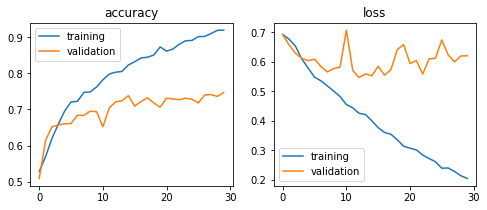

In [46]:
plot_history(history)

(1, 150, 150, 3)


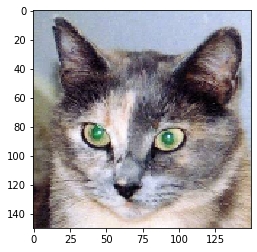

In [47]:
img_path = MYDIR+'/test/cats/cat.1700.jpg'
# We preprocess the image into a 4D tensor
from keras.preprocessing import image
img = image.load_img(img_path, target_size=(150, 150))
img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
# Remember that the model was trained on inputs with scaling
img_tensor /= 255.
print(img_tensor.shape)
plt.imshow(img_tensor[0])

Now we will see what the different features represent for this image. 
To extract the feature maps we want to look at, we will create a Keras model that takes batches of images as input, and outputs 
the activations of all convolution and pooling layers (maps the specified inputs to the specified outputs). 
This model class has multiple outputs. 

In [48]:
from tensorflow.keras import models

# Extracts the outputs of the top 8 layers:
layer_outputs = [layer.output for layer in model.layers[:8]]
# Creates a model that will return these outputs, given the model input:
activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

In [49]:
# This will return a list of 5 Numpy arrays: one array per layer activation
activations = activation_model.predict(img_tensor)

For example, we can look at the first activation layer. Its shape is the same as the output first layer (see model.summary())\
There are 32 feature maps in the first window, we can select any of them with the last index in the activation layer.\
The index we use in activations identify the layer itself.

In [50]:
first_layer_activation = activations[0]
print(first_layer_activation.shape)

(1, 148, 148, 32)


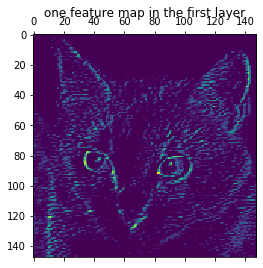

In [51]:
plt.matshow(first_layer_activation[0,:,:,3]);plt.title('one feature map in the first layer');

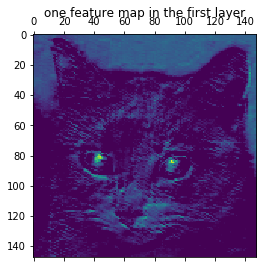

In [52]:
plt.matshow(first_layer_activation[0,:,:,30]);plt.title('one feature map in the first layer');

/home/dtrad/anaconda3/envs/tfgpu2/lib/python3.7/site-packages/ipykernel_launcher.py:28: RuntimeWarning: invalid value encountered in true_divide


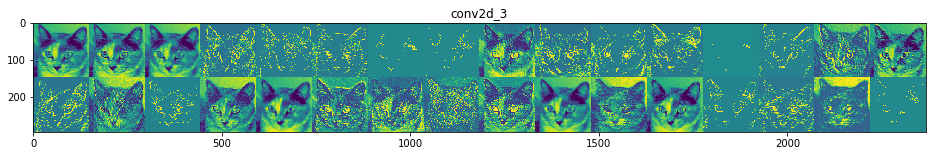

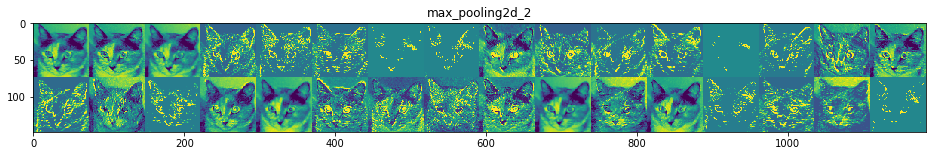

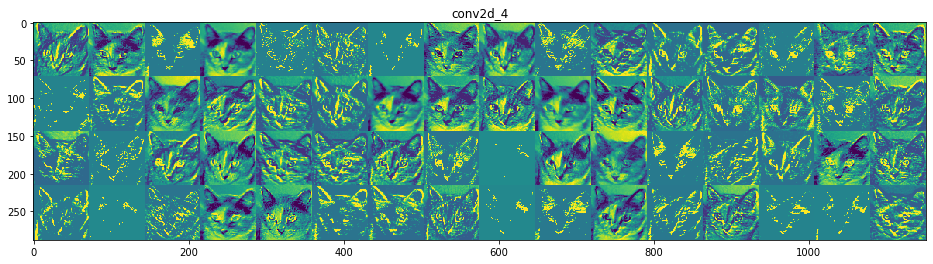

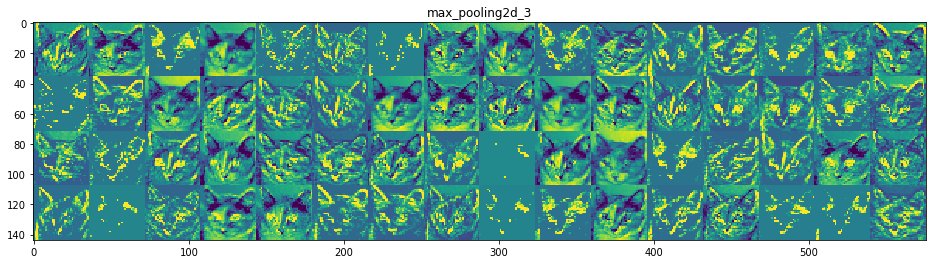

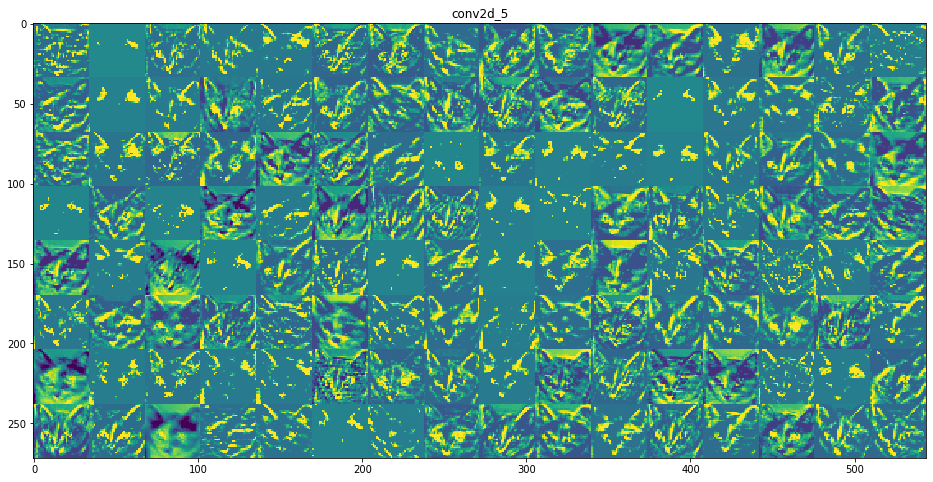

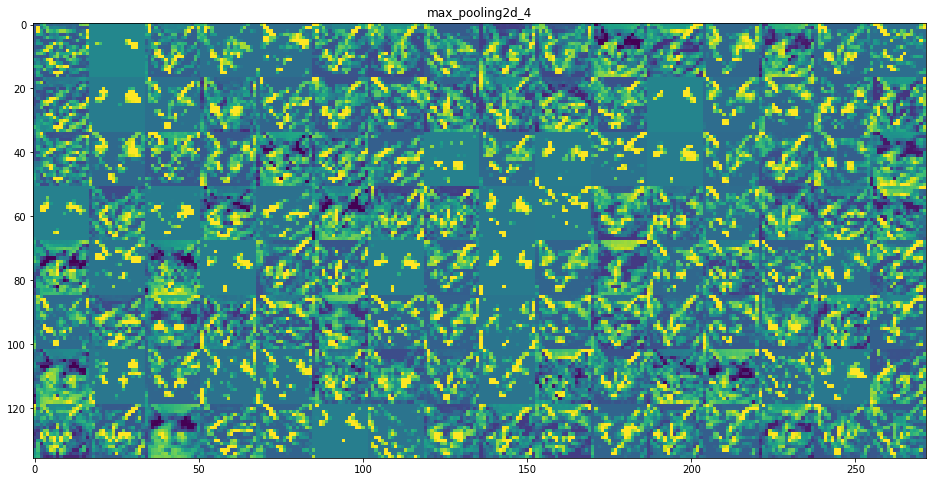

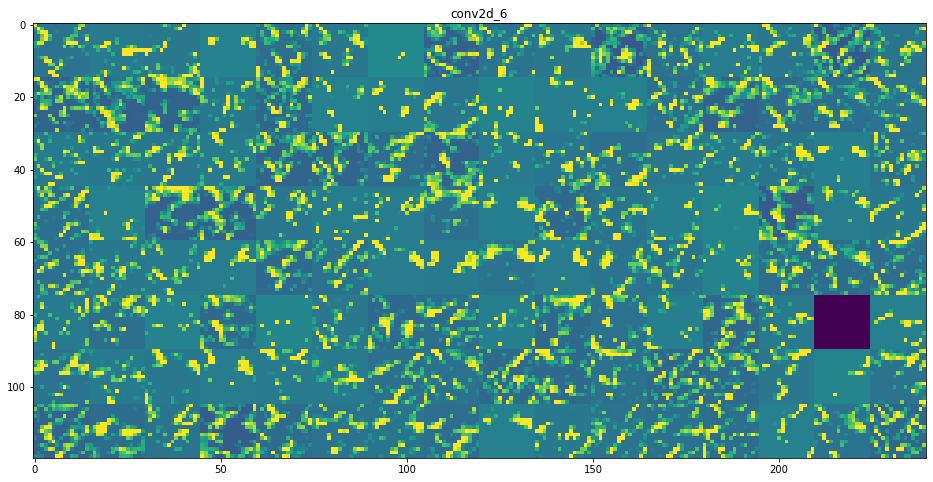

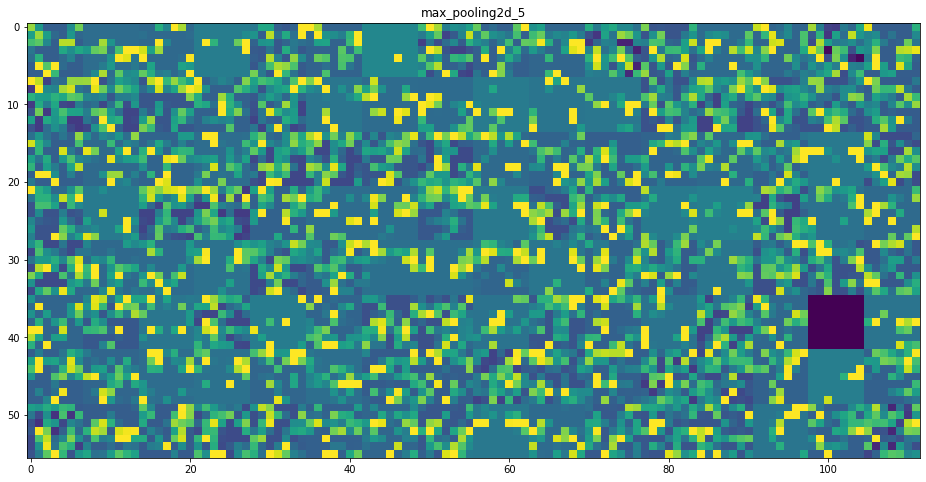

In [53]:
# These are the names of the layers, so can have them as part of our plot
layer_names = []
for layer in model.layers[:8]:
    layer_names.append(layer.name)

images_per_row = 16

# Now let's display our feature maps
for layer_name, layer_activation in zip(layer_names, activations):
    # This is the number of features in the feature map
    n_features = layer_activation.shape[-1]

    # The feature map has shape (1, size, size, n_features)
    size = layer_activation.shape[1]

    # We will tile the activation channels in this matrix
    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))

    # We'll tile each filter into this big horizontal grid
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,
                                             :, :,
                                             col * images_per_row + row]
            # Post-process the feature to make it visually palatable
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
                         row * size : (row + 1) * size] = channel_image

    # Display the grid
    scale = 1. / size
    plt.figure(figsize=(scale * display_grid.shape[1],
                        scale * display_grid.shape[0]))
    plt.title(layer_name)
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    
plt.show()